In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [138]:
df = pd.read_csv('/home/antonio/Uni/lab4/esperienze/rh_t/Gruppo03_2025-12-9T10-48-29.csv',
                 header=None, names=['HR (%)', 'T (°C)', 't (s)'])
df

,HR (%),T (°C),t (s)
0,48.07,19.78,0.802
1,48.07,19.78,1.203
2,48.04,19.79,1.604
3,48.07,19.79,2.005
4,48.04,19.78,2.406
...,...,...,...
18484,50.46,20.96,7198.634
18485,50.49,20.95,7199.035
18486,50.50,20.96,7199.436
18487,50.49,20.95,7199.837


In [139]:
HR = df['HR (%)'].values
T  = df['T (°C)'].values
time = df['t (s)'].values
N  = len(df)

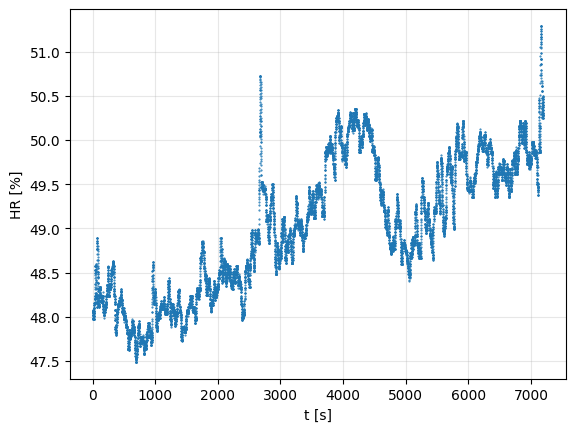

In [140]:
plt.plot(time, HR, marker='.', markersize=1, linestyle='None')
plt.xlabel('t [s]')
plt.ylabel('HR [%]')
plt.grid(alpha=0.3)
plt.show()

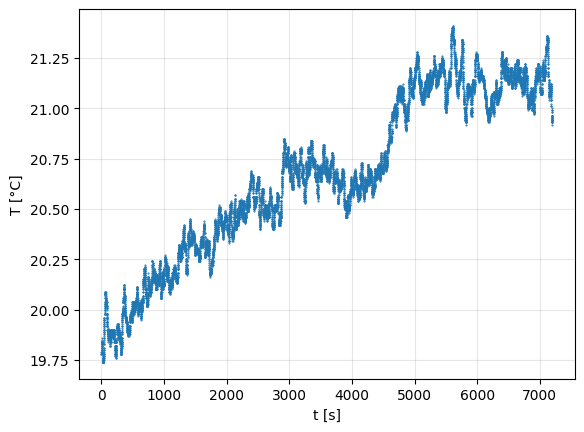

In [141]:
plt.plot(time, T, marker='.', markersize=1, linestyle='None')
plt.xlabel('t [s]')
plt.ylabel('T [°C]')
plt.grid(alpha=0.3)
plt.show()

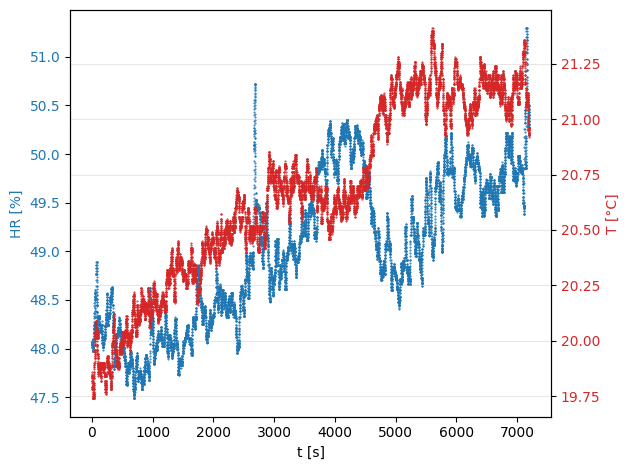

In [142]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('t [s]')
ax1.set_ylabel('HR [%]', color='tab:blue')
ax1.plot(time, HR, color='tab:blue', marker='.', markersize=1, linestyle='None', label='HR')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('T [°C]', color='tab:red')
ax2.plot(time, T, color='tab:red', marker='.', markersize=1, linestyle='None', label='T')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

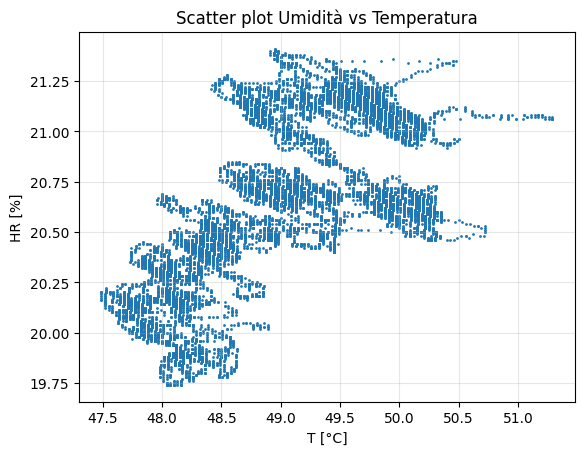

In [146]:
plt.scatter(HR, T, s=1)
# plt.scatter(T, HR, c=time, s=1)
plt.xlabel('T [°C]')
plt.ylabel('HR [%]')
plt.title('Scatter plot Umidità vs Temperatura')
# plt.colorbar(label='t [s]')
plt.grid(alpha=0.3)
plt.show()

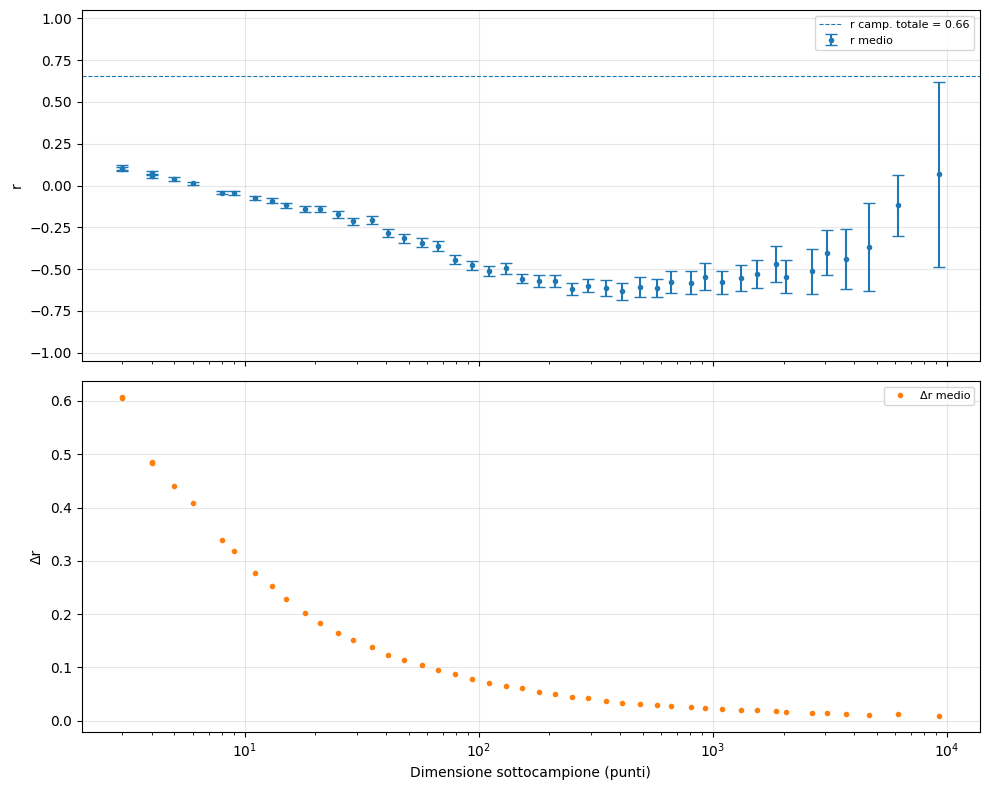

 n_splits  chunk_size   r_medio   std(r)  Δr_medio
        2        9244  0.067660 0.554698  0.008613
        3        6163 -0.118086 0.183026  0.012212
        4        4622 -0.367481 0.261441  0.011472
        5        3697 -0.439687 0.181381  0.013377
        6        3081 -0.400829 0.134312  0.015311
        7        2641 -0.513577 0.132302  0.014652
        9        2054 -0.543892 0.101426  0.016638
       10        1848 -0.469194 0.107243  0.018356
       12        1540 -0.527796 0.081939  0.019775
       14        1320 -0.554494 0.078598  0.020719
       17        1087 -0.578998 0.068632  0.022555
       20         924 -0.545481 0.079601  0.024143
       23         803 -0.580072 0.067860  0.025506
       28         660 -0.576476 0.063675  0.028300
       32         577 -0.613213 0.055545  0.029315
       38         486 -0.604877 0.059882  0.030872
       45         410 -0.631233 0.050325  0.033231
       53         348 -0.611615 0.046458  0.036907
       63         293 -0.599431

In [144]:
# ── Sequenza equi-spaziata in scala log ──────────────────────────────
N_POINTS = 50
n_splits_list = np.unique(np.round(np.logspace(np.log10(2), np.log10(N // 3), N_POINTS)).astype(int)).tolist()

# ── Calcolo r e Δr ───────────────────────────────────────────────────
def pearson_r_and_error(x, y):
    """Ritorna (r, Δr) oppure (nan, nan) se il chunk è degenere."""
    n = len(x)
    if n < 3:
        return np.nan, np.nan
    # std == 0 → correlazione indefinita
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    r = np.corrcoef(x, y)[0, 1]
    delta_r = np.sqrt((1 - r**2) / (n - 2))
    return r, delta_r

r_mean_list  = []
r_std_list   = []
dr_mean_list = []
chunk_sizes  = []
n_splits_used = []

for n_splits in n_splits_list:
    chunk = N // n_splits
    if chunk < 3:          # sottocampioni troppo piccoli, salta
        continue

    r_vals, dr_vals = [], []
    for i in range(n_splits):
        sl = slice(i * chunk, (i + 1) * chunk)
        r, dr = pearson_r_and_error(HR[sl], T[sl])
        if np.isfinite(r):          # scarta solo i chunk degeneri
            r_vals.append(r)
            dr_vals.append(dr)

    if len(r_vals) < 2:             # serve almeno 2 chunk validi per la std
        continue

    r_mean_list.append(np.mean(r_vals))
    r_std_list.append(np.std(r_vals, ddof=1)/np.sqrt(len(r_vals)))
    dr_mean_list.append(np.nanmean(dr_vals))
    chunk_sizes.append(chunk)
    n_splits_used.append(n_splits)

r_mean_list  = np.array(r_mean_list)
r_std_list   = np.array(r_std_list)
dr_mean_list = np.array(dr_mean_list)
chunk_sizes  = np.array(chunk_sizes)

# ── Plot ─────────────────────────────────────────────────────────────
r_global = np.corrcoef(HR, T)[0, 1]

fig, (ax_r, ax_dr) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_r.errorbar(chunk_sizes, r_mean_list, yerr=r_std_list,
              fmt='.', capsize=4, color='tab:blue', label='r medio')
ax_r.axhline(r_global, color='tab:blue', linestyle='--', linewidth=0.8,
             label=f'r camp. totale = {r_global:.2f}')
ax_r.set_ylabel('r')
ax_r.set_ylim(-1.05, 1.05)
ax_r.legend(fontsize=8)
ax_r.grid(alpha=0.3)

ax_dr.plot(chunk_sizes, dr_mean_list, '.', color='tab:orange', linestyle='None', label='Δr medio')
ax_dr.set_ylabel('Δr')
ax_dr.set_xlabel('Dimensione sottocampione (punti)')
ax_dr.legend(fontsize=8)
ax_dr.grid(alpha=0.3)

ax_r.set_xscale('log')
ax_dr.set_xscale('log')

plt.tight_layout()
plt.show()

# ── Riepilogo ────────────────────────────────────────────────────────
results = pd.DataFrame({
    'n_splits' : n_splits_used,
    'chunk_size': chunk_sizes,
    'r_medio'  : r_mean_list,
    'std(r)'   : r_std_list,
    'Δr_medio' : dr_mean_list
})
print(results.to_string(index=False))

$$\frac{r}{\Delta r} = r\sqrt{\frac{n - 2}{1 - r^2}}$$